In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
%load_ext autoreload
%autoreload 2
import numpy as np
import scipy as sp
import time
import random
def print_np(x):
    print ("Type is %s" % (type(x)))
    print ("Shape is %s" % (x.shape,))
#     print ("Values are: \n%s" % (x))


In [2]:
import os
import sys
sys.path.append('../')
from matplotlib import rc

# matplotlib.rcParams['text.usetex'] = True

# rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
# rc('text', usetex=True)


In [28]:
from model import UnicycleModel
from cost import UnicycleCost
from constraints import UnicycleConstraints
from matplotlib.patches import Ellipse
from utils.utils_alg import get_neighbor_vec,get_K_discrete
from utils.utils_alg import get_sample_eta_w,propagate_model
from utils.utils_plot import plot_traj,plot_traj_set,plot_state_input,plot_comparison,plot_two_funnel,plot_setting

from trajopt import trajopt
from Scaling import TrajectoryScaling

import cvxpy as cvx

In [4]:
N = 30
tf = 5
delT = tf/N

## obstacle setting

In [5]:
def get_H_obs(rx,ry) :
    return np.diag([1/rx,1/ry])
# obstacle
c_list = []
H_list = []
c1 = [1,2]
H1 = get_H_obs(0.75,1.5)
c_list.append(c1)
H_list.append(H1)
c2 = [4,3]
H2 = get_H_obs(0.75,1.5)
c_list.append(c2)
H_list.append(H2)

## initial and final conditions 

In [6]:
myModel = UnicycleModel.unicycle1('unicycle','analytic')

ix = myModel.ix
iu = myModel.iu
iw = myModel.iw
iq = myModel.iq
ip = myModel.ip

C = myModel.C
D = myModel.D
E = myModel.E
G = myModel.G

myCost = UnicycleCost.unicycle('Hello',ix,iu,N)
myConst = UnicycleConstraints.UnicycleConstraints('Hello',ix,iu)
myConst.set_obstacle(c_list,H_list)

In [7]:
xi = np.zeros(3)
xi[0] = 0.0
xi[1] = 0.0 
xi[2] = 0

xf = np.zeros(3)
xf[0] = 5.0
xf[1] = 5.0
xf[2] = 0

x0 = np.zeros((N+1,ix))
for i in range(N+1) :
    x0[i] = (N-i)/N * xi + i/N * xf
u0 = np.zeros((N+1,iu))

In [8]:
x_max = np.array([10,10,np.pi])
x_min = np.zeros(ix)

u_max = np.array([5,5])
u_min = np.zeros(iu)

traj_scaling = TrajectoryScaling(x_min,x_max,u_min,u_max,tf)

In [11]:
traj_solver= trajopt('unicycle',N,tf,20,myModel,myCost,myConst,Scaling=traj_scaling,
    type_discretization="foh",
    w_c=1,w_vc=1e3,w_tr=1e1,tol_vc=1e-6,tol_tr=1e-6,tol_dyn=1e-6,verbosity=True)

Is DPP?  True


In [12]:
_,_,xnom,unom,_,total_num_iter,_,_,_,_,history_nom = traj_solver.run(x0,u0,xi,xf)
tnom = np.array(range(N+1))*delT

Set parameter Username
Academic license - for non-commercial use only - expires 2024-11-27
┌──────────────────────────────────────────────────────────────────────────────────────────────┐

│                                              ..:: SCP ::..                                   │

├──────┬───────────┬──────────┬─────────┬───────────┬────────────┬─────────┬─────────┬─────────┤

│ iter │  total    │ final    │ input   │     -     │ total cost │ vc      │ tr      │ dyn     │

│      │  cost     │ time [s] │ energy  │     -     │ reduction  │ (log10) │         │         │

├──────┼───────────┼──────────┼─────────┼───────────┼────────────┼─────────┼─────────┼─────────┤

│1     │5043.172   │5.000     │30.6     │0          │-5.04e+03   │0(0.70  )│0(1.262 )│0(0.609 )│
│2     │91.793     │5.000     │47.4     │0          │4.95e+03    │1(-12.22)│0(4.437 )│0(0.175 )│
│3     │80.927     │5.000     │69.3     │0          │10.9        │1(-10.38)│0(1.163 )│0(0.079 )│
│4     │75.397     │5.000     

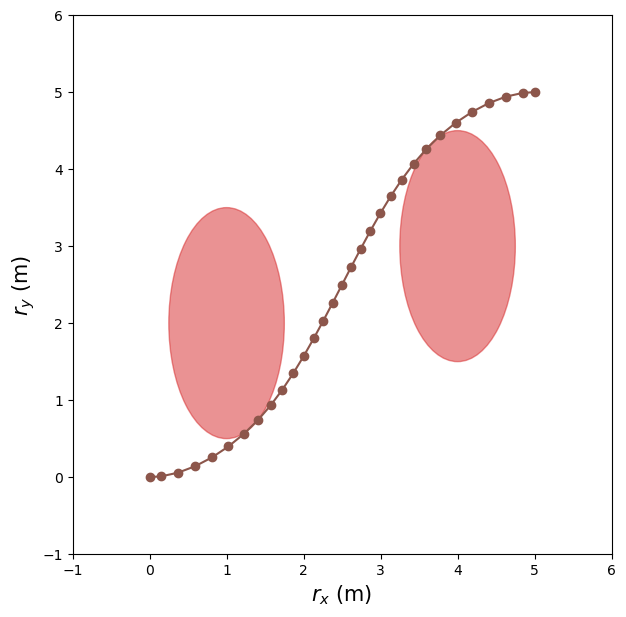

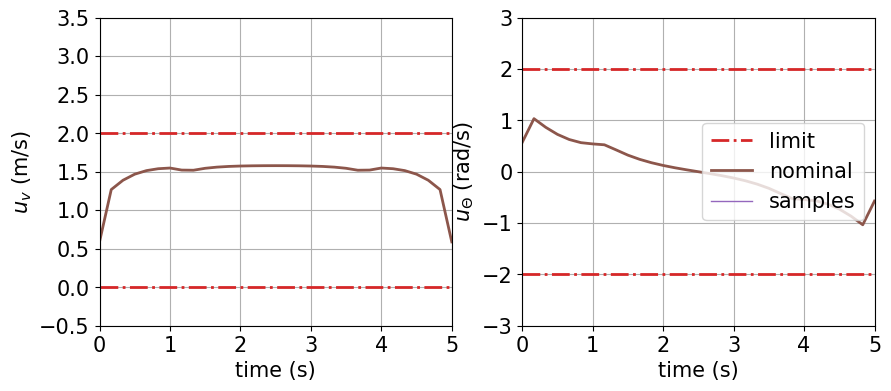

In [13]:
fS = 15
plt.figure(0,figsize=(15,7))
ax = plt.gca()
for ce,H in zip(c_list,H_list) :
    rx = 1/H[0,0]
    ry = 1/H[1,1]
    circle1 = Ellipse((ce[0],ce[1]),rx*2,ry*2,color='tab:red',alpha=0.5,fill=True)
    ax.add_patch(circle1)
plt.plot(xnom[:,0],xnom[:,1],'o-',color='tab:brown',label='traj w/o funnel')
# plot_traj_set(x0,u0,c_list,H_list,Q0,xi=xi,xf=xf,Qi=Qini,Qf=Qf,plt=plt)
plt.axis([-1.0, 6.0, -1.0, 6.0])
plt.gca().set_aspect('equal', adjustable='box')
plt.axis([-1.0, 6.0, -1.0, 6.0])
plt.xlabel('$r_x$ (m)', fontsize = fS)
plt.ylabel('$r_y$ (m)', fontsize = fS)


plt.figure(1,figsize=(10,4))
plt.subplot(121)
plt.plot(tnom, unom[:,0]*0+myConst.vmax,'-.',color='tab:red',alpha=1.0,linewidth=2.0,label='limit')
plt.plot(tnom, unom[:,0]*0+myConst.vmin,'-.',color='tab:red',alpha=1.0,linewidth=2.0)
plt.plot(tnom, unom[:,0],'-',color='tab:brown',alpha=1.0,linewidth=2.0,label='nominal')
plt.plot(1e3, 1e3,'-',color='tab:purple',alpha=1.0,linewidth=1.0,label='samples')
plt.xlabel('time (s)', fontsize = fS)
plt.ylabel('$u_v$ (m/s)', fontsize = fS)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.axis([0.0, tf, -0.5, 3.5])
plt.grid(True)

plt.subplot(122)
plt.plot(tnom, unom[:,1]*0+myConst.wmax,'-.',color='tab:red',alpha=1.0,linewidth=2.0)
plt.plot(tnom, unom[:,1]*0+myConst.wmin,'-.',color='tab:red',alpha=1.0,linewidth=2.0,label='limit')
plt.plot(tnom, unom[:,1],'-',color='tab:brown',alpha=1.0,linewidth=2.0,label='nominal')
plt.plot(1e3, 1e3,'-',color='tab:purple',alpha=1.0,linewidth=1.0,label='samples')
plt.xlabel('time (s)', fontsize = fS)
plt.ylabel('$u_{\Theta}$ (rad/s)', fontsize = fS)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.axis([0.0, tf, -3, 3])
plt.legend(fontsize=fS)
plt.rcParams["font.family"] = "Times New Roman"
plt.grid(True)

# Funnel synthesis

In [14]:
# new obstacles
def get_H_obs(rx,ry) :
    return np.diag([1/rx,1/ry])
# obstacle
c_list = []
H_list = []
c1 = [1.5,2.75]
H1 = get_H_obs(0.5,0.7)
c_list.append(c1)
H_list.append(H1)
c2 = [4,3.5]
H2 = get_H_obs(0.5,0.7)
c_list.append(c2)
H_list.append(H2)

In [15]:
# get A,B,F - we already have C,D,E,G
A,B = myModel.diff(xnom,unom)
F = myModel.diff_F(xnom,unom,np.zeros((N+1,iw)))

# Qmax,Rmax,Ynom,Knom
Qmax = []
for i in range(N+1) :
    Qmax.append(np.diag([0.4**2,0.4**2,np.deg2rad(20)**2])*5) 
Rmax = myConst.get_Rmax(unom)

Qini = np.diag([0.08,0.08,0.06])
Qf = np.diag([0.08,0.08,0.06])
Ynom,Knom = myConst.get_YKnom(A,B,Qmax,Rmax)

alpha = 0.7 # 0.5
lambda_mu = 0.5 # 0.5

const_input = myConst.get_const_input(xnom,unom)
const_state = myConst.get_const_state(xnom,unom,c_list,H_list)

In [16]:
# Lipschitz
from Lipschitz import Lipschitz
lip_estimator = Lipschitz(ix,iu,iq,ip,iw,N,num_sample=100,flag_uniform=True)
lip_estimator.initialize(xnom,unom,Qmax,Knom,A,B,C,D,E,F,G,myModel)

gamma = lip_estimator.update_lipschitz_norm(myModel)

In [17]:
x_max = np.array([1,1,np.pi])
x_min = np.zeros(ix)

u_max = np.array([1,1]) 
u_min = np.zeros(iu)

funl_scaling = TrajectoryScaling(x_min,x_max,u_min,u_max,tf)

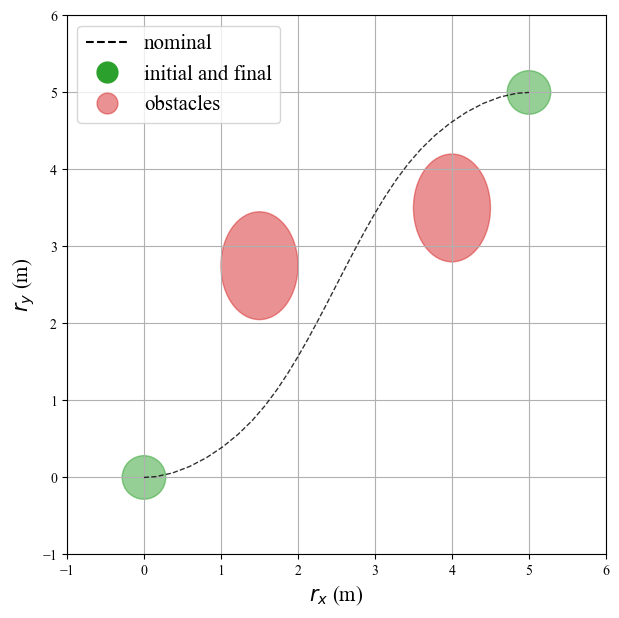

In [31]:
plt.figure(figsize=(7,7))
plot_setting(xnom,xi=xnom[0],xf=xnom[-1],Qi=Qini,Qf=Qf,plt=plt)
plt.grid(True)

ax = plt.gca()
for ce,H in zip(c_list,H_list) :
    rx = 1/H[0,0]
    ry = 1/H[1,1]
    circle1 = Ellipse((ce[0],ce[1]),rx*2,ry*2,color='tab:red',alpha=0.5,fill=True)
    ax.add_patch(circle1)
plt.grid(True)
filepath = '/Users/taewankim/Documents/Code/ForPapers/2023_LCSS_Synthesis_by_OCP/image/'
plt.savefig(filepath + 'simulation_initial.pdf',bbox_inches='tight')

In [18]:
from nl_funlopt_by_COP import nl_funlopt_by_COP
from nl_funlopt_by_OCP import nl_funlopt_by_OCP
from model.LMImodel import LMI_linear_systems, RK4

In [19]:
myLMI = LMI_linear_systems('test',ix,iu,alpha+lambda_mu,"analytic")

In [20]:
funl_solver1 = nl_funlopt_by_OCP(ix,iu,iq,ip,iw,N,delT,
                             myLMI,funl_scaling,
                             myModel,
                             max_iter=1)

In [21]:
funl_solver2 = nl_funlopt_by_COP(ix,iu,iq,ip,iw,N,delT,
                             funl_scaling,
                             myModel,
                             max_iter=1)

In [22]:
funl_solver1.cvx_initialize(alpha,lambda_mu,Qmax=Qmax,Qini=Qini,Qf=Qf,const_state=const_state,const_input=const_input)
# funl_solver1.cvx_initialize(alpha,lambda_mu,Qini=Qini,Qf=Qf,const_state=const_state,const_input=const_input)

Is DPP?  True


In [23]:
Q1,K1,Y1,Z1,sv1,cost1 = funl_solver1.run(xnom,unom,Qmax,Ynom,Qmax,gamma,C,D,E,F,G)
print("support-value",sv1)
print("cost",cost1)

support-value [0.06827488 0.07672354 0.08621768 0.09688667 0.10887589 0.12234871
 0.13748873 0.15450224 0.17362109 0.19510579 0.21924912 0.24638005
 0.2768683  0.31112931 0.34962994 0.39289482 0.4415135  0.4961485
 0.55754429 0.62653748 0.70406823 0.791193   0.88909901 0.99912038
 0.99999999 0.99999999 0.99999999 0.99999999 0.99999999 0.99999999
 1.        ]
cost 70.23586694022296


In [24]:
S1 = [Q/sv for Q,sv in zip(Q1,sv1)]

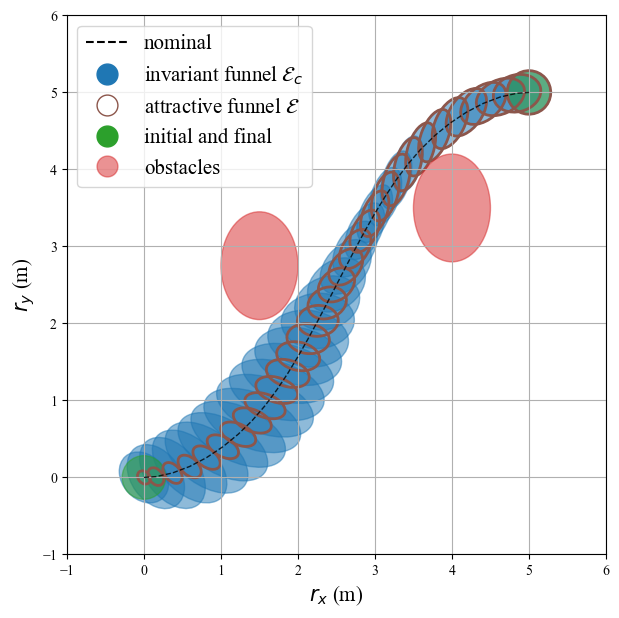

In [25]:
plt.figure(figsize=(7,7))
plot_two_funnel(xnom,Q1,S1,xi=xnom[0],xf=xnom[-1],Qi=Qini,Qf=Qf,plt=plt)
plt.grid(True)

ax = plt.gca()
for ce,H in zip(c_list,H_list) :
    rx = 1/H[0,0]
    ry = 1/H[1,1]
    circle1 = Ellipse((ce[0],ce[1]),rx*2,ry*2,color='tab:red',alpha=0.5,fill=True)
    ax.add_patch(circle1)
plt.grid(True)

In [26]:
# funl_solver2.cvx_initialize(alpha,lambda_mu,Qini=Qini,Qf=Qf,Qmax=Qmax,Rmax=Rmax)
# funl_solver2.cvx_initialize(alpha,lambda_mu,Qini=Qini,Qf=Qf,const_input=const_input)
funl_solver2.cvx_initialize(alpha,lambda_mu,Qmax=Qmax,Qini=Qini,Qf=Qf,const_state=const_state,const_input=const_input)

Is DPP?  True


In [27]:
Q2,K2,Y2,sv2,cost2 = funl_solver2.run(gamma,A,B,C,D,E,F,G)
print("support-value",sv2)
print("cost",cost2)

optimal
support-value [0.0902152  0.10137886 0.11392397 0.12802146 0.14386345 0.16166581
 0.18167111 0.20415196 0.2294147  0.25780357 0.28970542 0.32555496
 0.36584068 0.41111156 0.46198447 0.51915264 0.58339507 0.65558717
 0.73671266 0.82787701 0.93032248 0.99999983 0.99999994 0.99999995
 0.99999997 0.99999996 0.99999996 0.99999995 0.99999995 0.99999992
 0.99999999]
cost 92.13968346612238


In [ ]:
S2 = [Q/sv for Q,sv in zip(Q2,sv2)]

In [ ]:
plt.figure(figsize=(7,7))
plot_two_funnel(xnom,Q2,S2,xi=xnom[0],xf=xnom[-1],Qi=Qini,Qf=Qf,plt=plt)
plt.grid(True)

ax = plt.gca()
for ce,H in zip(c_list,H_list) :
    rx = 1/H[0,0]
    ry = 1/H[1,1]
    circle1 = Ellipse((ce[0],ce[1]),rx*2,ry*2,color='tab:red',alpha=0.5,fill=True)
    ax.add_patch(circle1)
plt.grid(True)

In [ ]:
from scipy.integrate import solve_ivp
from scipy import interpolate
Yfoh = interpolate.interp1d(tnom,Y1,axis=0)
Zfoh = interpolate.interp1d(tnom,Z1,axis=0)
ufoh = interpolate.interp1d(tnom,unom,axis=0)
svfoh_inv = interpolate.interp1d(tnom,1/sv1,axis=0)
idx_x = slice(0,ix)
idx_q = slice(ix,ix+ix*ix)
def vec(Q) :
    return Q.flatten('F')
def dfdt(t,V) :
    u = ufoh(t)
    x = V[idx_x]
    dxdt = myModel.forward(x,u).squeeze()
    return dxdt
def dFdt(t,V) :
    u = ufoh(t)
    y = vec(Yfoh(t))
    z = vec(Zfoh(t))
    x = V[idx_x]
    q = V[idx_q]
    A,B = myModel.diff(x,u)
    dxdt = myModel.forward(x,u).squeeze()
    dqdt = myLMI.forward(q,y,z,A,B)
    dV = np.hstack((dxdt,dqdt))
    return dV

In [ ]:
tfwd = np.linspace(0,tf,1000)
xfwd = []
qfwd = []
for i in range(N) :
    V0 = np.zeros(ix+ix*ix)
    V0[idx_x] = xnom[i]
    V0[idx_q] = vec(Q1[i])
    if i == N - 1 :
        t_eval = tfwd[np.logical_and(tfwd >= delT*i,tfwd <= delT*(i+1))]
    else :
        t_eval = tfwd[np.logical_and(tfwd >= delT*i,tfwd < delT*(i+1))]
    sol = solve_ivp(dFdt,(delT*i,delT*(i+1)),V0,t_eval=t_eval)
    xfwd.append(sol.y.T[:,idx_x])
    qfwd.append(sol.y.T[:,idx_q])
    
xfwd = np.vstack(xfwd)
qfwd = np.vstack(qfwd)
Qfwd = []
for q in qfwd :
    Qfwd.append(q.reshape((ix,ix),order='F'))
Qfwd = np.array(Qfwd)    
ufwd = ufoh(tfwd)
Qfwd_inv = np.linalg.inv(Qfwd)
Yfwd = Yfoh(tfwd)
Kfwd = Yfwd@Qfwd_inv
svfwd = 1/(svfoh_inv(tfwd))  
    

In [ ]:
def get_state_margin_by_funnel(Q,sv) :
    N = len(Q) - 1
    a1 = np.array([1,0,0])
    a2 = np.array([0,1,0])
    a3 = np.array([0,0,1])
    xfunl1 = []
    yfunl1 = []
    tfunl1 = []
    for i in range(N+1) :
        xfunl1.append(np.sqrt(a1.T@Q[i]/sv[i]@a1))
        yfunl1.append(np.sqrt(a2.T@Q[i]/sv[i]@a2))
        tfunl1.append(np.sqrt(a3.T@Q[i]/sv[i]@a3))
    xfunl1 = np.array(xfunl1)
    yfunl1 = np.array(yfunl1)
    tfunl1 = np.array(tfunl1)
    return xfunl1,yfunl1,tfunl1
def get_input_margin_by_funnel(Q,K,sv) :
    N = len(Q) - 1
    R1 = []
    for i in range(N+1) :
        R1.append(K[i]@Q[i]/sv[i]@K[i].T)
    a1 = np.array([1,0])
    a2 = np.array([0,1])
    vfunl1 = []
    wfunl1 = []
    for i in range(N+1) :
        vfunl1.append(np.sqrt(a1.T@R1[i]@a1))
        wfunl1.append(np.sqrt(a2.T@R1[i]@a2))
    vfunl1 = np.array(vfunl1)
    wfunl1 = np.array(wfunl1)
    return vfunl1,wfunl1

In [ ]:
xfunl2,yfunl2,thfunl2 = get_state_margin_by_funnel(Qfwd,svfwd)
vfunl2,wfunl2 = get_input_margin_by_funnel(Qfwd,Kfwd,svfwd)

xfunl2_n,yfunl2_n,thfunl2_n = get_state_margin_by_funnel(Q1,sv1)
vfunl2_n,wfunl2_n = get_input_margin_by_funnel(Q1,K1,sv1)

In [ ]:
plt.figure(1,figsize=(13,3))
plt.subplot(131)
plt.plot(tnom, xnom[:,0],'-',color='black',alpha=1.0,linewidth=2.0,label='nominal')

plt.plot(tfwd, xfwd[:,0]+xfunl2,'--',color='tab:blue',alpha=1.0,linewidth=2.0)
plt.plot(tfwd, xfwd[:,0]-xfunl2,'--',color='tab:blue',alpha=1.0,linewidth=2.0)
plt.xlabel('time (s)', fontsize = fS)
plt.ylabel('$x$ (m/s)', fontsize = fS)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.axis([0.0, tf, -0.5, 5.5])
plt.grid(True)

plt.subplot(132)
plt.plot(tnom, xnom[:,1],'-',color='black',alpha=1.0,linewidth=2.0,label='nominal')

plt.plot(tfwd, xfwd[:,1]+yfunl2,'--',color='tab:blue',alpha=1.0,linewidth=2.0)
plt.plot(tfwd, xfwd[:,1]-yfunl2,'--',color='tab:blue',alpha=1.0,linewidth=2.0)

plt.xlabel('time (s)', fontsize = fS)
plt.ylabel('$y$ (m/s)', fontsize = fS)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.axis([0.0, tf, -0.5, 5.5])
plt.grid(True)

plt.subplot(133)
plt.plot(tnom, xnom[:,2],'-',color='black',alpha=1.0,linewidth=2.0,label='nominal')

plt.plot(tfwd, xfwd[:,2]+thfunl2,'--',color='tab:blue',alpha=1.0,linewidth=2.0)
plt.plot(tfwd, xfwd[:,2]-thfunl2,'--',color='tab:blue',alpha=1.0,linewidth=2.0)

plt.xlabel('time (s)', fontsize = fS)
plt.ylabel('$theta$ (rad)', fontsize = fS)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.axis([0.0, tf, -np.deg2rad(90), np.deg2rad(120)])
plt.legend(fontsize=fS)
plt.rcParams["font.family"] = "Times New Roman"
plt.grid(True)


In [ ]:
plt.figure(1,figsize=(13,3))
plt.subplot(121)
ax = plt.gca()

ax.plot(tfwd, ufwd[:,0]*0+myConst.vmax,'-.',color='tab:red',alpha=1.0,linewidth=2.0,label='limit')
ax.plot(tfwd, ufwd[:,0]*0+myConst.vmin,'-.',color='tab:red',alpha=1.0,linewidth=2.0)
ax.plot(tfwd, ufwd[:,0],'--',color='black',alpha=1.0,linewidth=2.0,label='nominal')

ax.plot(tfwd, ufwd[:,0]+vfunl2,'-',color='tab:blue',alpha=1.0,linewidth=2.0)
ax.plot(tfwd, ufwd[:,0]-vfunl2,'-',color='tab:blue',alpha=1.0,linewidth=2.0)
ax.plot(tnom, unom[:,0]+vfunl2_n,'o',color='tab:blue',alpha=1.0,linewidth=2.0)
ax.plot(tnom, unom[:,0]-vfunl2_n,'o',color='tab:blue',alpha=1.0,linewidth=2.0)

ax.set_xlabel('time (s)', fontsize = fS)
ax.set_ylabel('$u_v$ (m/s)', fontsize = fS)
# ax.set_xticks(fontsize=15)
# ax.set_yticks(fontsize=15)
ax.axis([0.0, tf, -0.5, 2.5])
ax.grid(True)

plt.subplot(122)
ax = plt.gca()
ax.plot(tfwd, ufwd[:,1]*0+myConst.wmax,'-.',color='tab:red',alpha=1.0,linewidth=2.0)
ax.plot(tfwd, ufwd[:,1]*0+myConst.wmin,'-.',color='tab:red',alpha=1.0,linewidth=2.0,label='limit')
ax.plot(tfwd, ufwd[:,1],'--',color='black',alpha=1.0,linewidth=2.0,label='nominal')

ax.plot(tfwd, ufwd[:,1]+wfunl2,'-',color='tab:blue',alpha=1.0,linewidth=2.0,label='funnel')
ax.plot(tnom, unom[:,1]+wfunl2_n,'o',color='tab:blue',alpha=1.0,linewidth=2.0)
ax.plot(tfwd, ufwd[:,1]-wfunl2,'-',color='tab:blue',alpha=1.0,linewidth=2.0)
ax.plot(tnom, unom[:,1]-wfunl2_n,'o',color='tab:blue',alpha=1.0,linewidth=2.0)

ax.set_xlabel('time (s)', fontsize = fS)
ax.set_ylabel('$u_{\Theta}$ (rad/s)', fontsize = fS)
# plt.xticks(fontsize=15)
# plt.yticks(fontsize=15)
ax.axis([0.0, tf, -3, 3])
ax.legend(fontsize=fS,loc=1)

ax.grid(True)

# generate samples

In [ ]:
import scipy

In [ ]:
x0_sample = []
num_sample = 50
for i in range(num_sample) :
    z = np.random.randn(ix)
    z = z / np.linalg.norm(z)
    x_s = xnom[0] + scipy.linalg.sqrtm(Q1[0]/sv1[0])@z
    x0_sample.append(x_s)
    
for i in range(num_sample) :
    z = np.random.randn(ix)
    z = z / np.linalg.norm(z)
    x_s = xnom[0] + scipy.linalg.sqrtm(Q1[0])@z
    x0_sample.append(x_s)
# tsam,xsam,usam,wsam,xsamp = get_sample_trajectory(xi,x0_sample,xbar,ubar,Qbar,Ybar,myModel,N,ix,iu,iw,delT,
#                                             flag_noise=True)

In [ ]:
# ufwd,Qfwd,Yfwd
def dfdt_with_nominal(t,X,w) :
    xnom = X[:ix]
    xnew = X[ix:ix*2]
    q = X[ix*2:]
    Q = q.reshape((ix,ix),order='F')
    
    Y = Yfoh(t)
    y = vec(Y)
    
    Z = Zfoh(t)
    z = vec(Z)
    
    K = Y@np.linalg.inv(Q)
     
    unom = ufoh(t)
    unew = unom + K@(xnew-xnom)

    dfnom = np.squeeze(myModel.forward(xnom,unom))
    dfnew = np.squeeze(myModel.forward_uncertain(xnew,unew,w))
    A,B = myModel.diff(xnom,unom)
    dqdt = myLMI.forward(q,y,z,A,B)
    
    return np.hstack((dfnom,dfnew,dqdt))

In [ ]:
list_xsam = []
list_svsam = []

list_tsam = []

for x_s in x0_sample :
    z = np.random.randn(iw)
    w = z / np.linalg.norm(z)
    for i in range(N) :

        X0 = np.zeros(2*ix+ix*ix)
        X0[:ix] = xnom[i]
        if i == 0 :
            X0[ix:2*ix] = x_s
        else :
            X0[ix:2*ix] = xtmp

        X0[2*ix:] = vec(Q1[i])

        t_eval = tfwd[np.logical_and(tfwd >= delT*i,tfwd <= delT*(i+1))]
        
        if t_eval[-1] != delT*(i+1) :
            t_eval = np.append(t_eval,delT*(i+1))
        
        sol = solve_ivp(dfdt_with_nominal,(delT*i,delT*(i+1)),X0,args=(w,),
            t_eval=t_eval,rtol=1e-6,atol=1e-10)

        # measure the value
        xn = sol.y.T[:,:ix]
        xs = sol.y.T[:,ix:2*ix]
        qn = sol.y.T[:,2*ix:]
        Qn = []
        for q in qn :
            Qn.append(q.reshape((ix,ix),order='F'))
        Qn = np.array(Qn)
        Qn_inv = np.linalg.inv(Qn)
        eta = xs - xn
        sv = np.squeeze(np.transpose(eta[:,:,np.newaxis],(0,2,1))@Qn_inv@eta[:,:,np.newaxis])

        # saving
        if i == 0:
            xsam = xs
            svsam = sv
            tsam = sol.t
        else :
            xsam = np.append(xsam,xs,axis=0)
            svsam = np.append(svsam,sv,axis=0)
            tsam = np.append(tsam,sol.t,axis=0)

        xtmp = xs[-1]
    tsam = np.array(tsam)
    list_svsam.append(svsam)
    list_xsam.append(xsam)
    list_tsam.append(tsam)

In [ ]:
plt.figure(figsize=(10,10))
plot_two_funnel(xnom,Q1,S1,xi=xnom[0],xf=xnom[-1],Qi=Qini,Qf=Qf,plt=plt)
for xsam in list_xsam :
    plt.plot(xsam[:,0],xsam[:,1],'-',color='tab:purple')
plt.grid(True)

In [ ]:
exponential_decay = np.exp(-alpha*(tfwd)) / sv1[0]

# plot together for paper

In [ ]:
fig, axd = plt.subplot_mosaic([['upper left', 'upper right'],
                               ['lower', 'lower']],figsize=(8,5),layout="constrained")
plt.rcParams['pdf.fonttype'] = 42
# plt.rcParams["font.family"] = "Times New Roman"
ax = axd['upper left']

ax.plot(tfwd, ufwd[:,0]*0+myConst.vmax,'-.',color='tab:red',alpha=1.0,linewidth=2.0,label='limit')
ax.plot(tfwd, ufwd[:,0]*0+myConst.vmin,'-.',color='tab:red',alpha=1.0,linewidth=2.0)
ax.plot(tfwd, ufwd[:,0],'--',color='black',alpha=1.0,linewidth=2.0,label='nominal')

ax.plot(tfwd, ufwd[:,0]+vfunl2,'-',color='tab:blue',alpha=1.0,linewidth=2.0)
ax.plot(tfwd, ufwd[:,0]-vfunl2,'-',color='tab:blue',alpha=1.0,linewidth=2.0)
ax.plot(tnom, unom[:,0]+vfunl2_n,'o',color='tab:blue',alpha=1.0,linewidth=2.0)
ax.plot(tnom, unom[:,0]-vfunl2_n,'o',color='tab:blue',alpha=1.0,linewidth=2.0)

ax.set_xlabel('time (s)', fontsize = fS)
ax.set_ylabel('$u_v$ (m/s)', fontsize = fS)
# ax.set_xticks(fontsize=15)
# ax.set_yticks(fontsize=15)
ax.axis([0.0, tf, -0.5, 2.5])
ax.grid(True)

ax = axd['upper right']
ax.plot(tfwd, ufwd[:,1]*0+myConst.wmax,'-.',color='tab:red',alpha=1.0,linewidth=2.0)
ax.plot(tfwd, ufwd[:,1]*0+myConst.wmin,'-.',color='tab:red',alpha=1.0,linewidth=2.0,label='limit')
ax.plot(tfwd, ufwd[:,1],'--',color='black',alpha=1.0,linewidth=2.0,label='nominal')

ax.plot(tfwd, ufwd[:,1]+wfunl2,'-',color='tab:blue',alpha=1.0,linewidth=2.0,label='funnel')
ax.plot(tnom, unom[:,1]+wfunl2_n,'o',color='tab:blue',alpha=1.0,linewidth=2.0)
ax.plot(tfwd, ufwd[:,1]-wfunl2,'-',color='tab:blue',alpha=1.0,linewidth=2.0)
ax.plot(tnom, unom[:,1]-wfunl2_n,'o',color='tab:blue',alpha=1.0,linewidth=2.0)

ax.set_xlabel('time (s)', fontsize = fS)
ax.set_ylabel('$u_{\Theta}$ (rad/s)', fontsize = fS)
# plt.xticks(fontsize=15)
# plt.yticks(fontsize=15)
ax.axis([0.0, tf, -3, 3])
ax.legend(fontsize=fS,loc=1)

ax.grid(True)

ax = axd['lower']

ax.plot(tfwd,1/svfwd,color='tab:blue',label='$1/c(t)$')
ax.plot(tnom,1/sv1,'o',color='tab:blue')
ax.plot(tfwd,exponential_decay,'--',color='tab:orange',label='$e^{-{ \\alpha}(t-t_0)}/c(t_0)$')
plt.plot(tfwd,0*tfwd+1,'--',color='tab:red',label='$1$')
for tsam,sv_sam in zip(list_tsam,list_svsam) :
    ax.plot(tsam,sv_sam,'-.',color='tab:purple')
ax.grid(True)
ax.set_xlabel('time (s)', fontsize = fS)
ax.set_title(r'$(x-\bar{x})^{\top} Q^{-1} (x-\bar{x})$', fontsize = fS)
ax.plot(1e3,1e3,'-.',color='tab:purple',label='samples')
ax.axis([-0.2,5.2,-0.5,16])
ax.legend(fontsize=15)
# ax.set_yticks([0,1,2,3,4,5,6,7,8])
# plt.yticks(range(0,13))
    
    
# plt.tight_layout()

# filepath = '/Users/taewankim/Documents/Code/ForPapers/2023FunnelbyOCPSubmission/'
# plt.savefig(filepath + 'input_result.pdf',bbox_inches='tight')#,pad_inches=0.5)

In [ ]:
plt.figure(figsize=(7,7))
plt.rcParams['pdf.fonttype'] = 42
plot_two_funnel(xnom,Q1,S1,xi=xnom[0],xf=xnom[-1],Qi=Qini,Qf=Qf,plt=plt)
plt.grid(True)

ax = plt.gca()
for ce,H in zip(c_list,H_list) :
    rx = 1/H[0,0]
    ry = 1/H[1,1]
    circle1 = Ellipse((ce[0],ce[1]),rx*2,ry*2,color='tab:red',alpha=0.5,fill=True)
    ax.add_patch(circle1)
plt.grid(True)

plt.text(-0.3,-0.7,'Initial',fontsize=15)
plt.text(4.7,5.4,'Final',fontsize=15)


# filepath = '/Users/taewankim/Documents/Code/ForPapers/2023FunnelbyOCPSubmission/'
# plt.savefig(filepath + 'funnel_result.pdf',bbox_inches='tight')#,pad_inches=0.5)